In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, HistGradientBoostingRegressor
import optuna
import joblib
import warnings
from tqdm import TqdmWarning

warnings.filterwarnings("ignore", category=TqdmWarning)

c:\Users\jaime\Desktop\proyecto-7-grupo-4-prediccion-precios-coches-dashboard\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Cargamos los datos para nuestro modelo

In [2]:
df = pd.read_csv("../csv/clean_cars2.csv")

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 192378 entries, 0 to 192377
Data columns (total 24 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   brand            192378 non-null  object 
 1   model            192378 non-null  object 
 2   model_year       192378 non-null  int64  
 3   milage           192378 non-null  int64  
 4   fuel_type        192378 non-null  object 
 5   transmission     192378 non-null  object 
 6   ext_col          192378 non-null  object 
 7   int_col          192378 non-null  object 
 8   accident         192378 non-null  int64  
 9   clean_title      192378 non-null  int64  
 10  price            192378 non-null  int64  
 11  brand_id         192378 non-null  int64  
 12  model_id         192378 non-null  int64  
 13  transmission_id  192378 non-null  int64  
 14  ext_col_id       192378 non-null  int64  
 15  int_col_id       192378 non-null  int64  
 16  engine_liters    192378 non-null  floa

#### Preparamos x e y

In [3]:
# Target
y = df['price']

# Features (SOLO numéricas)
x = df.drop(columns=[
    'price',
    'brand',
    'transmission',
    'int_col',
    'ext_col',
    'model',
    'fuel_type',
])

y_log = np.log1p(y)

x_train, x_test, y_train, y_test = train_test_split(
    x, y_log, test_size=0.2, random_state=42
)

y_test_real = np.expm1(y_test)


#### Métricas de evaluación

In [4]:
def evaluate_model(y_true, y_pred):
    return{
        'MAE': mean_absolute_error(y_true, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_true, y_pred)),
        'R2': r2_score(y_true, y_pred)
    }

#### Optimización de Hiperparametros con optuna

##### Random Forest (RF)

In [5]:
def objective_rf(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 600),
        "max_depth": trial.suggest_int("max_depth", 3, 30),
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 20),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 10),
        "max_features": trial.suggest_categorical("max_features", ["sqrt", "log2"]),
        "random_state": 42,
        "n_jobs": -1
    }

    model = RandomForestRegressor(**params)

    score = cross_val_score(
        model,
        x,
        y,
        cv=3,
        scoring="neg_root_mean_squared_error"
    ).mean()

    return -score

##### Gradient Boosting (GBR)

In [6]:
def objective_gb(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 500),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 20),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 10),
        "random_state": 42
    }

    model = GradientBoostingRegressor(**params)

    score = cross_val_score(
        model,
        x,
        y,
        cv=3,
        scoring="neg_root_mean_squared_error"
    ).mean()

    return -score


##### Hist Gradient Boosting Regressor (HGB)

In [7]:
def objective_hgb(trial):
    params = {
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "max_depth": trial.suggest_int("max_depth", 3, 15),
        "max_iter": trial.suggest_int("max_iter", 100, 600),
        "l2_regularization": trial.suggest_float("l2_regularization", 1e-6, 10.0, log=True),
        "max_leaf_nodes": trial.suggest_int("max_leaf_nodes", 15, 255),
        "random_state": 42
    }

    model = HistGradientBoostingRegressor(**params)

    score = cross_val_score(
        model,
        x,
        y,
        cv=3,
        scoring="neg_root_mean_squared_error"
    ).mean()

    return -score

#### Ejecutar Optuna

##### RF

In [8]:
study_rf = optuna.create_study(direction="minimize")
study_rf.optimize(objective_rf, n_trials=3)

print("Mejores hiperparámetros:")
print(study_rf.best_params)
print("Mejor RMSE:", study_rf.best_value)

[I 2026-02-02 13:54:26,693] A new study created in memory with name: no-name-249286d5-52ba-43e0-bc2c-601b3c6461af
[I 2026-02-02 13:54:51,560] Trial 0 finished with value: 39790.6574154582 and parameters: {'n_estimators': 179, 'max_depth': 10, 'min_samples_split': 2, 'min_samples_leaf': 7, 'max_features': 'log2'}. Best is trial 0 with value: 39790.6574154582.
[I 2026-02-02 13:55:29,337] Trial 1 finished with value: 39562.10090711128 and parameters: {'n_estimators': 217, 'max_depth': 21, 'min_samples_split': 17, 'min_samples_leaf': 6, 'max_features': 'sqrt'}. Best is trial 1 with value: 39562.10090711128.
[I 2026-02-02 13:56:39,222] Trial 2 finished with value: 39555.55683522206 and parameters: {'n_estimators': 383, 'max_depth': 29, 'min_samples_split': 14, 'min_samples_leaf': 8, 'max_features': 'log2'}. Best is trial 2 with value: 39555.55683522206.


Mejores hiperparámetros:
{'n_estimators': 383, 'max_depth': 29, 'min_samples_split': 14, 'min_samples_leaf': 8, 'max_features': 'log2'}
Mejor RMSE: 39555.55683522206


##### GBR

In [9]:
study_gbr = optuna.create_study(direction="minimize")
study_gbr.optimize(objective_gb, n_trials=3)

print("Mejores hiperparámetros:")
print(study_gbr.best_params)
print("Mejor RMSE:", study_gbr.best_value)

[I 2026-02-02 13:56:39,237] A new study created in memory with name: no-name-4759992e-6b42-49c9-a122-325450d40596
[I 2026-02-02 13:59:18,162] Trial 0 finished with value: 39682.38545648098 and parameters: {'n_estimators': 164, 'learning_rate': 0.023144095896114287, 'max_depth': 7, 'subsample': 0.8373827644037793, 'min_samples_split': 9, 'min_samples_leaf': 8}. Best is trial 0 with value: 39682.38545648098.
[I 2026-02-02 14:01:42,458] Trial 1 finished with value: 40484.606683392914 and parameters: {'n_estimators': 110, 'learning_rate': 0.011913355094372344, 'max_depth': 10, 'subsample': 0.8422923481833623, 'min_samples_split': 6, 'min_samples_leaf': 9}. Best is trial 0 with value: 39682.38545648098.
[I 2026-02-02 14:14:45,097] Trial 2 finished with value: 40416.324024851194 and parameters: {'n_estimators': 499, 'learning_rate': 0.053532233425874175, 'max_depth': 10, 'subsample': 0.9610584758325522, 'min_samples_split': 18, 'min_samples_leaf': 9}. Best is trial 0 with value: 39682.385456

Mejores hiperparámetros:
{'n_estimators': 164, 'learning_rate': 0.023144095896114287, 'max_depth': 7, 'subsample': 0.8373827644037793, 'min_samples_split': 9, 'min_samples_leaf': 8}
Mejor RMSE: 39682.38545648098


##### HGB

In [10]:
study_hgb = optuna.create_study(direction="minimize")
study_hgb.optimize(objective_hgb, n_trials=4)

print("Mejores hiperparámetros:")
print(study_hgb.best_params)
print("Mejor RMSE:", study_hgb.best_value)

[I 2026-02-02 14:14:45,112] A new study created in memory with name: no-name-1d1f2750-13e4-47c6-95d1-0ad88f296b80
[I 2026-02-02 14:14:53,422] Trial 0 finished with value: 39721.236596068404 and parameters: {'learning_rate': 0.02407447610923777, 'max_depth': 15, 'max_iter': 482, 'l2_regularization': 1.1088369553099429e-05, 'max_leaf_nodes': 27}. Best is trial 0 with value: 39721.236596068404.
[I 2026-02-02 14:14:55,319] Trial 1 finished with value: 39830.05255474129 and parameters: {'learning_rate': 0.22386884242931662, 'max_depth': 9, 'max_iter': 168, 'l2_regularization': 1.6458485637446507, 'max_leaf_nodes': 151}. Best is trial 0 with value: 39721.236596068404.
[I 2026-02-02 14:14:59,764] Trial 2 finished with value: 39807.113680420494 and parameters: {'learning_rate': 0.04780718892025827, 'max_depth': 4, 'max_iter': 448, 'l2_regularization': 0.00014032046876165236, 'max_leaf_nodes': 108}. Best is trial 0 with value: 39721.236596068404.
[I 2026-02-02 14:15:04,820] Trial 3 finished wit

Mejores hiperparámetros:
{'learning_rate': 0.02994567260289465, 'max_depth': 15, 'max_iter': 597, 'l2_regularization': 2.9398880349600543e-06, 'max_leaf_nodes': 45}
Mejor RMSE: 39707.9890994503


#### Random Forest Regressor

In [11]:
# Random Forest
rf = RandomForestRegressor(
    **study_rf.best_params,
    random_state=42,
    n_jobs=1
)

rf.fit(x_train, y_train)

# Predicciones (log → real)
y_pred_rf_train = np.expm1(rf.predict(x_train))
y_pred_rf_test  = np.expm1(rf.predict(x_test))

#### Gradient Boosting

In [12]:
# Gradient Boosting
gbr = GradientBoostingRegressor(
    **study_gbr.best_params,
    random_state=42
)

gbr.fit(x_train, y_train)

# Predicciones (log → real)
y_pred_gbr_train = np.expm1(gbr.predict(x_train))
y_pred_gbr_test  = np.expm1(gbr.predict(x_test))

####  HGB

In [13]:
hgb = HistGradientBoostingRegressor(
    **study_hgb.best_params,
    random_state=42
)

hgb.fit(x_train, y_train)

# Predicciones (log → real)
y_pred_hgb_train = np.expm1(hgb.predict(x_train))
y_pred_hgb_test  = np.expm1(hgb.predict(x_test))

#### Elección del modelo


#### Análisis de errores

##### Predicción vs real

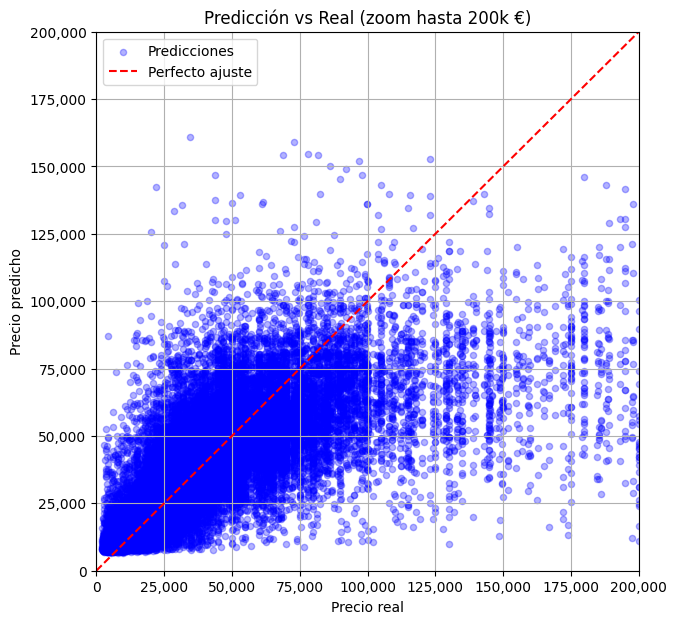

In [14]:
plt.figure(figsize=(7,7))
plt.scatter(y_test_real, np.expm1(gbr.predict(x_test)),
            alpha=0.3, s=20, color='blue', label='Predicciones')

plt.plot([0, 200_000], [0, 200_000], linestyle='--', color='red', label='Perfecto ajuste')

plt.xlim(0, 200_000)
plt.ylim(0, 200_000)

plt.xlabel('Precio real')
plt.ylabel('Precio predicho')
plt.title('Predicción vs Real (zoom hasta 200k €)')

plt.gca().xaxis.set_major_formatter(mtick.StrMethodFormatter('{x:,.0f}'))
plt.gca().yaxis.set_major_formatter(mtick.StrMethodFormatter('{x:,.0f}'))

plt.grid(True)
plt.legend()
plt.show()


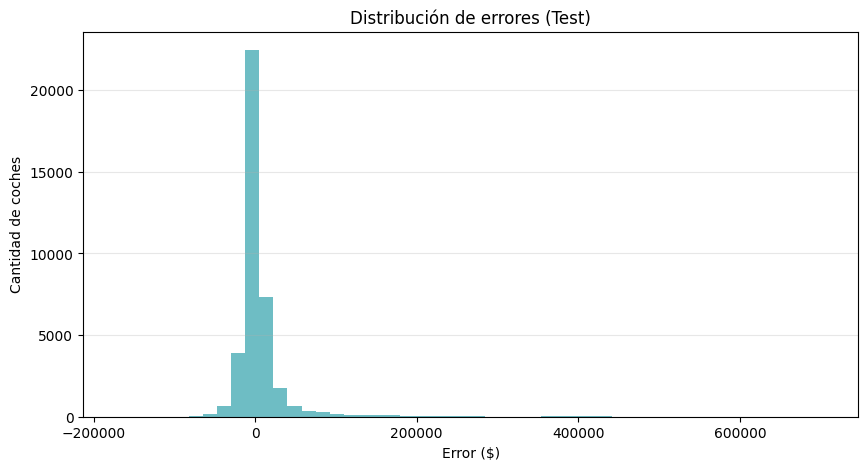

In [15]:
# Predicciones de test
y_pred_gbr_test = np.expm1(gbr.predict(x_test))

# Errores
errors = y_test_real - y_pred_gbr_test

# Histograma
plt.figure(figsize=(10,5))
plt.hist(errors, bins=50, color='#31A2AC', alpha=0.7)
plt.title('Distribución de errores (Test)')
plt.xlabel('Error ($)')
plt.ylabel('Cantidad de coches')
plt.grid(axis='y', alpha=0.3)
plt.show()


#### Comparar modelos

##### Comprobar overfiting de los modelos (%)

In [16]:
# Revertir y reales
y_train_real = np.expm1(y_train)
y_test_real  = np.expm1(y_test)

y_pred_gbr_train = np.expm1(gbr.predict(x_train))
y_pred_gbr_test  = np.expm1(gbr.predict(x_test))

y_pred_rf_train  = np.expm1(rf.predict(x_train))
y_pred_rf_test   = np.expm1(rf.predict(x_test))

y_pred_hgb_train = np.expm1(hgb.predict(x_train))
y_pred_hgb_test  = np.expm1(hgb.predict(x_test))

In [17]:
# MAE
mae_train_gbr = mean_absolute_error(y_train_real, y_pred_gbr_train)
mae_test_gbr  = mean_absolute_error(y_test_real, y_pred_gbr_test)

mae_train_rf = mean_absolute_error(y_train_real, y_pred_rf_train)
mae_test_rf  = mean_absolute_error(y_test_real, y_pred_rf_test)

mae_train_hgb = mean_absolute_error(y_train_real, y_pred_hgb_train)
mae_test_hgb  = mean_absolute_error(y_test_real, y_pred_hgb_test)

In [18]:
overfit_gbr = (mae_test_gbr - mae_train_gbr) / mae_train_gbr * 100
overfit_rf  = (mae_test_rf  - mae_train_rf)  / mae_train_rf  * 100
overfit_hgb = (mae_test_hgb - mae_train_hgb) / mae_train_hgb * 100

print("Overfitting (%) por modelo:")
print(f"GBR: {overfit_gbr:.2f}%")
print(f"RF:  {overfit_rf:.2f}%")
print(f"HGB: {overfit_hgb:.2f}%")

Overfitting (%) por modelo:
GBR: 2.32%
RF:  10.70%
HGB: 3.70%


##### Ver valores MAE, RMSE Y R2 de los modelos.

In [19]:
# --- Asegurarnos de tener y_train_real ---
y_train_real = np.expm1(y_train)

# --- Evaluar modelos en TRAIN ---
results_train = {
    'RF': evaluate_model(y_train_real, y_pred_rf_train),
    'GBR': evaluate_model(y_train_real, y_pred_gbr_train),
    'HGB': evaluate_model(y_train_real, y_pred_hgb_train),
}

# --- Convertir a DataFrame para ver resultados ---
pd.DataFrame(results_train).T

,MAE,RMSE,R2
RF,14051.833326,38500.763607,0.381613
GBR,15322.866866,40272.168837,0.323401
HGB,15028.553133,39338.271520,0.354417


#### Guardar modelos y predicciones

In [20]:
joblib.dump(hgb, "../models/csv2/hgb_model.pkl")
joblib.dump(y_test_real, "../models/csv2/y_test_real.pkl")
joblib.dump(y_pred_hgb_test, "../models/csv2/y_pred_hgb.pkl")

print("Modelo y predicciones guardadas ✅")

Modelo y predicciones guardadas ✅
